In [ ]:
import anndata as ad
import pandas as pd
import numpy as np
import os 

meta = pd.read_csv('../data/metaDataIndex.csv')#.sort_values(by='genotyping_id').reset_index(drop=True)
data = np.load('../data/normAlleleDosagemat.npy')
adata = ad.AnnData(X=data,obs=meta)

data_dir = '../data'
splits = sorted([os.path.join(data_dir,f) for f in os.listdir(data_dir) if f.startswith('pcScores')])

for s in splits:
    split_no = s.split('.')[2][-2:]
    pcs = pd.read_csv(s)
    adata.obsm[f'pcSplit_{split_no}'] = pcs.values[:,:-2].astype(float)

/opt/anaconda3/envs/pfs/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [128]:
adata.obsm['pcSplit_10'][:,-1].sum()

np.float64(8.668621376273222e-13)

In [129]:
adata.obs.columns

Index(['hgdp_id', 'population_id', 'population_name', 'country_of_origin',
       'geo_region_of_origin', 'genotyping_id', 'sex'],
      dtype='object')

K-Nearest Neighbors Classifier

In [130]:
from collections import Counter
def nearest_neighbors_classifier(
    adata,
    y_col='geo_region_of_origin',
    obsm_key='pcSplit_10',
    n_folds=5,
    k_neighbors=5,
):
    adata = adata.copy()

    # encode classes
    classes = sorted(adata.obs[y_col].unique().tolist())
    class_dict = {c: i for i, c in enumerate(classes)}
    adata.obs['class_id'] = adata.obs[y_col].map(class_dict)

    # remove classes with too few samples
    class_counts = adata.obs['class_id'].value_counts()
    keep_classes = class_counts[class_counts >= n_folds].index
    adata = adata[adata.obs['class_id'].isin(keep_classes)].copy()

    # assign stratified folds with shuffling within class
    adata.obs['fold'] = -1
    rng = np.random.default_rng(0)

    for cls in adata.obs['class_id'].unique():
        idx = np.where(adata.obs['class_id'].to_numpy() == cls)[0]
        rng.shuffle(idx)
        for j, row_idx in enumerate(idx):
            adata.obs.iloc[row_idx, adata.obs.columns.get_loc('fold')] = j % n_folds

    adata.obs['pred'] = -1
    fold_ids = sorted(adata.obs['fold'].unique().tolist())

    for fold in fold_ids:
        test_mask = adata.obs['fold'].to_numpy() == fold
        train_mask = ~test_mask

        X_train = adata.obsm[obsm_key][train_mask]
        X_test = adata.obsm[obsm_key][test_mask]
        y_train = adata.obs.loc[train_mask, 'class_id'].to_numpy()

        # standardize using training data only
        mu = X_train.mean(axis=0)
        sigma = X_train.std(axis=0)
        sigma[sigma == 0] = 1.0

        X_train = (X_train - mu) / sigma
        X_test = (X_test - mu) / sigma

        # squared Euclidean distances
        dists = np.sum((X_test[:, None, :] - X_train[None, :, :]) ** 2, axis=2)

        nn_idx = np.argpartition(dists, k_neighbors - 1, axis=1)[:, :k_neighbors]

        preds = []
        for idx in nn_idx:
            labels = y_train[idx]
            preds.append(Counter(labels).most_common(1)[0][0])

        adata.obs.loc[test_mask, 'pred'] = preds

    return adata
adata = nearest_neighbors_classifier(adata,k_neighbors=1)

In [131]:
adata.obs['geo_region_of_origin'].value_counts()
adata.obs[['geo_region_of_origin','class_id']]

,geo_region_of_origin,class_id
0,EUROPE,4
1,EUROPE,4
2,EUROPE,4
3,EUROPE,4
4,EUROPE,4
...,...,...
1102,EAST_ASIA,3
1103,EAST_ASIA,3
1104,EAST_ASIA,3
1105,EAST_ASIA,3


[[ 40   1  19 182   4   5   2]
 [  5   3   3  39   2   5   5]
 [ 18   1  89  99   5  10   7]
 [ 32   3  31 145   8   7   3]
 [ 10   2  20  84  22  11   0]
 [  9   0  26  91  11  20   1]
 [  0   2   6   7   1   0  11]]
[[0.15810277 0.00395257 0.07509881 0.71936759 0.01581028 0.01976285
  0.00790514]
 [0.08064516 0.0483871  0.0483871  0.62903226 0.03225806 0.08064516
  0.08064516]
 [0.07860262 0.00436681 0.38864629 0.43231441 0.02183406 0.04366812
  0.03056769]
 [0.13973799 0.01310044 0.13537118 0.63318777 0.0349345  0.03056769
  0.01310044]
 [0.06711409 0.01342282 0.13422819 0.56375839 0.14765101 0.0738255
  0.        ]
 [0.05696203 0.         0.16455696 0.57594937 0.06962025 0.12658228
  0.00632911]
 [0.         0.07407407 0.22222222 0.25925926 0.03703704 0.
  0.40740741]]


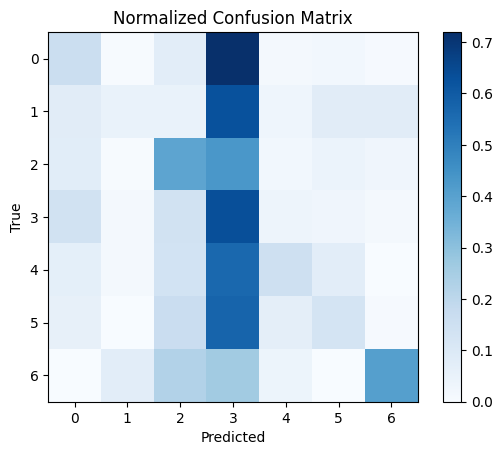

In [135]:
from sklearn.metrics import roc_auc_score,f1_score

from sklearn.metrics import confusion_matrix

y_true = adata.obs['class_id'].to_numpy()
y_pred = adata.obs['pred'].to_numpy()

cm = confusion_matrix(y_true, y_pred)
print(cm)

cm_norm = cm / cm.sum(axis=1, keepdims=True)
print(cm_norm)

import matplotlib.pyplot as plt

plt.imshow(cm_norm, cmap='Blues')
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix")
plt.show()

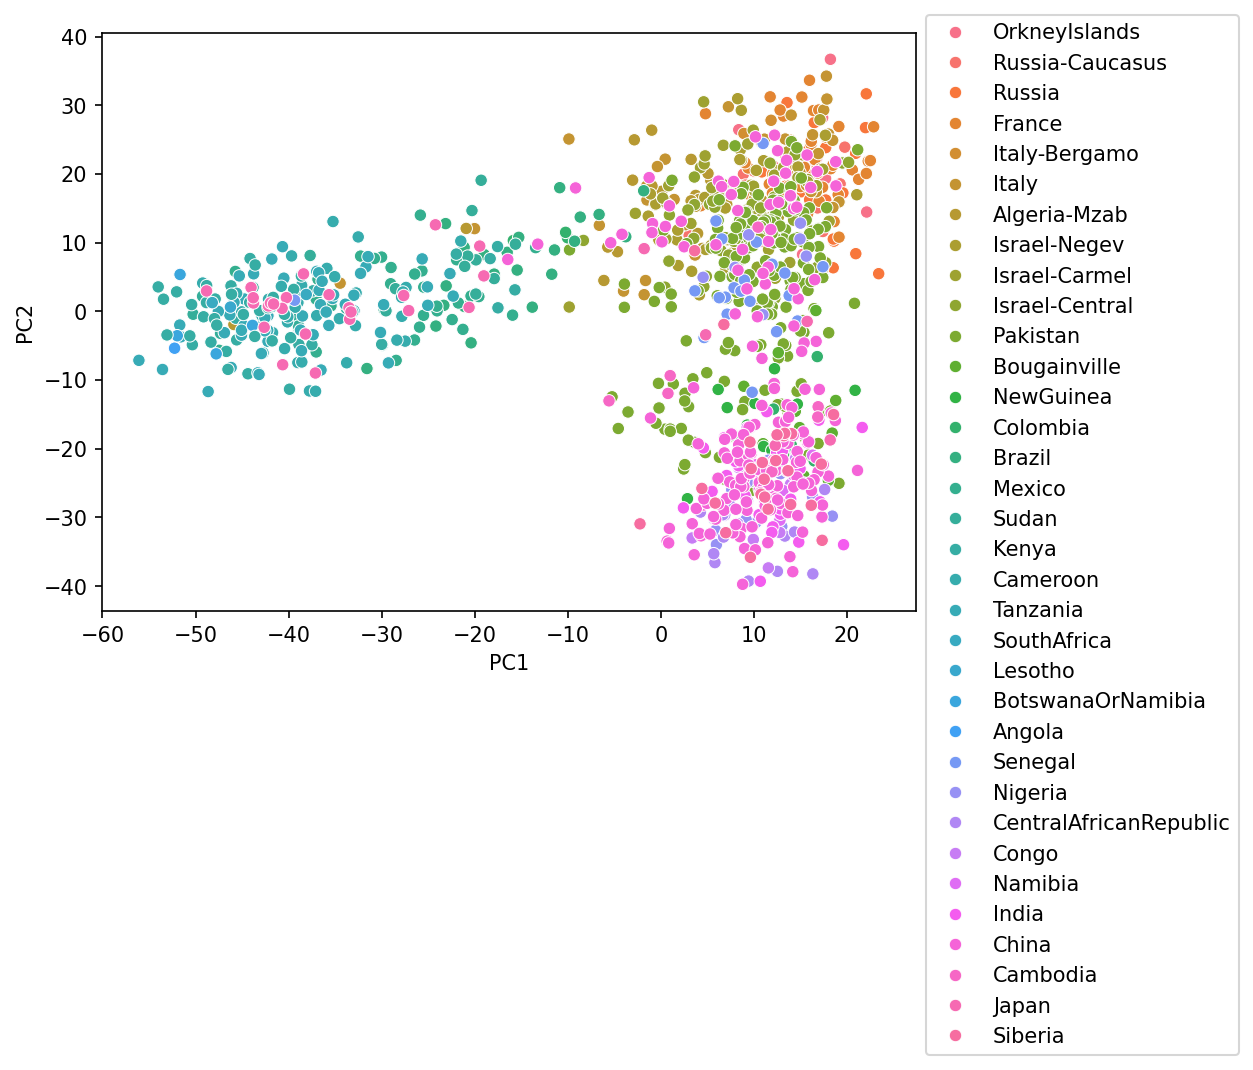

In [142]:
from umap import UMAP
import seaborn as sns
# coords = UMAP(n_components=2).fit_transform(adata.obsm['pcSplit_10'])
adata.obs[['PC1','PC2']] = adata.obsm['pcSplit_10'][:,:2]
# adata.obs[['UMAP1','UMAP2']] = coords
fig,ax = plt.subplots(figsize=(7,5),dpi=150)
sns.scatterplot(data = adata.obs, x= 'PC1',y='PC2',hue='country_of_origin')
ax.legend(bbox_to_anchor=(1,1.05))

In [113]:
print(np.unique(adata.obs['pred'], return_counts=True))
print(np.unique(adata.obs['class_id'], return_counts=True))

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 29, 30, 31, 33, 34, 35,
       36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 48, 49, 50, 51, 53, 54,
       55, 56, 57, 58, 59, 60, 61]), array([  2,  12,   7,  24,  10,   6,  13,  41,   1,   9,   6,  21,  11,
         5,   3,   5,   2,   2,   3,  51,   6,   4,   5,   2,   1, 154,
         9,   2,   1,  14,   7,  13,   3,  16,  13,  21,  85,   2,   3,
        11,  24,  20,   1,  11,   6,  11,   4,   3,  29,  26,   7,   6,
         1,  47,  53, 195,  24,  25]))
(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61]), array([15, 24, 11, 24, 45, 20, 15, 23, 18, 24, 23,  8,  7, 10, 10, 41, 28,
       19, 18, 34, 10, 22,  9, 18, 12, 29, 23, 14,  8, 1